## Nicolas Lo - Project A

In [1]:
import os.path
import struct
from array import array
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import random

from sklearn import svm, metrics
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

### Step 1 – Load and explore Fashion‑MNIST

In this step I load the Fashion‑MNIST training and test sets using the provided `MnistDataloader` helper class, and visualise some example images from both sets. This mirrors the loading and visualisation code from the tutorial notebook.

In [2]:
# Fashion-MNIST Data Loader Class 
class MnistDataloader(object):
    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError(
                    "Magic number mismatch, expected 2049, got {}".format(magic)
                )
            labels = array("B", file.read())

        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError(
                    "Magic number mismatch, expected 2051, got {}".format(magic)
                )
            image_data = array("B", file.read())

        images = []
        for i in range(size):
            # load each image as a 1D 784‑element array 
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            images.append(img)

        return np.array(images), np.array(labels)

    def load_data(self):
        x_train, y_train = self.read_images_labels(
            self.training_images_filepath, self.training_labels_filepath
        )
        x_test, y_test = self.read_images_labels(
            self.test_images_filepath, self.test_labels_filepath
        )
        return x_train, y_train, x_test, y_test


# Specify paths to Fashion‑MNIST images/labels
input_path = "comp0014_coursework/Fashion_MNIST"

training_images_filepath = os.path.join(input_path, "train-images-idx3-ubyte")
training_labels_filepath = os.path.join(input_path, "train-labels-idx1-ubyte")
test_images_filepath     = os.path.join(input_path, "t10k-images-idx3-ubyte")
test_labels_filepath     = os.path.join(input_path, "t10k-labels-idx1-ubyte")

# Load Fashion‑MNIST dataset
fashion_dataloader = MnistDataloader(
    training_images_filepath,
    training_labels_filepath,
    test_images_filepath,
    test_labels_filepath,
)

x_train, y_train, x_test, y_test = fashion_dataloader.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 784) (60000,)
(10000, 784) (10000,)


Visualise a random selection of images:

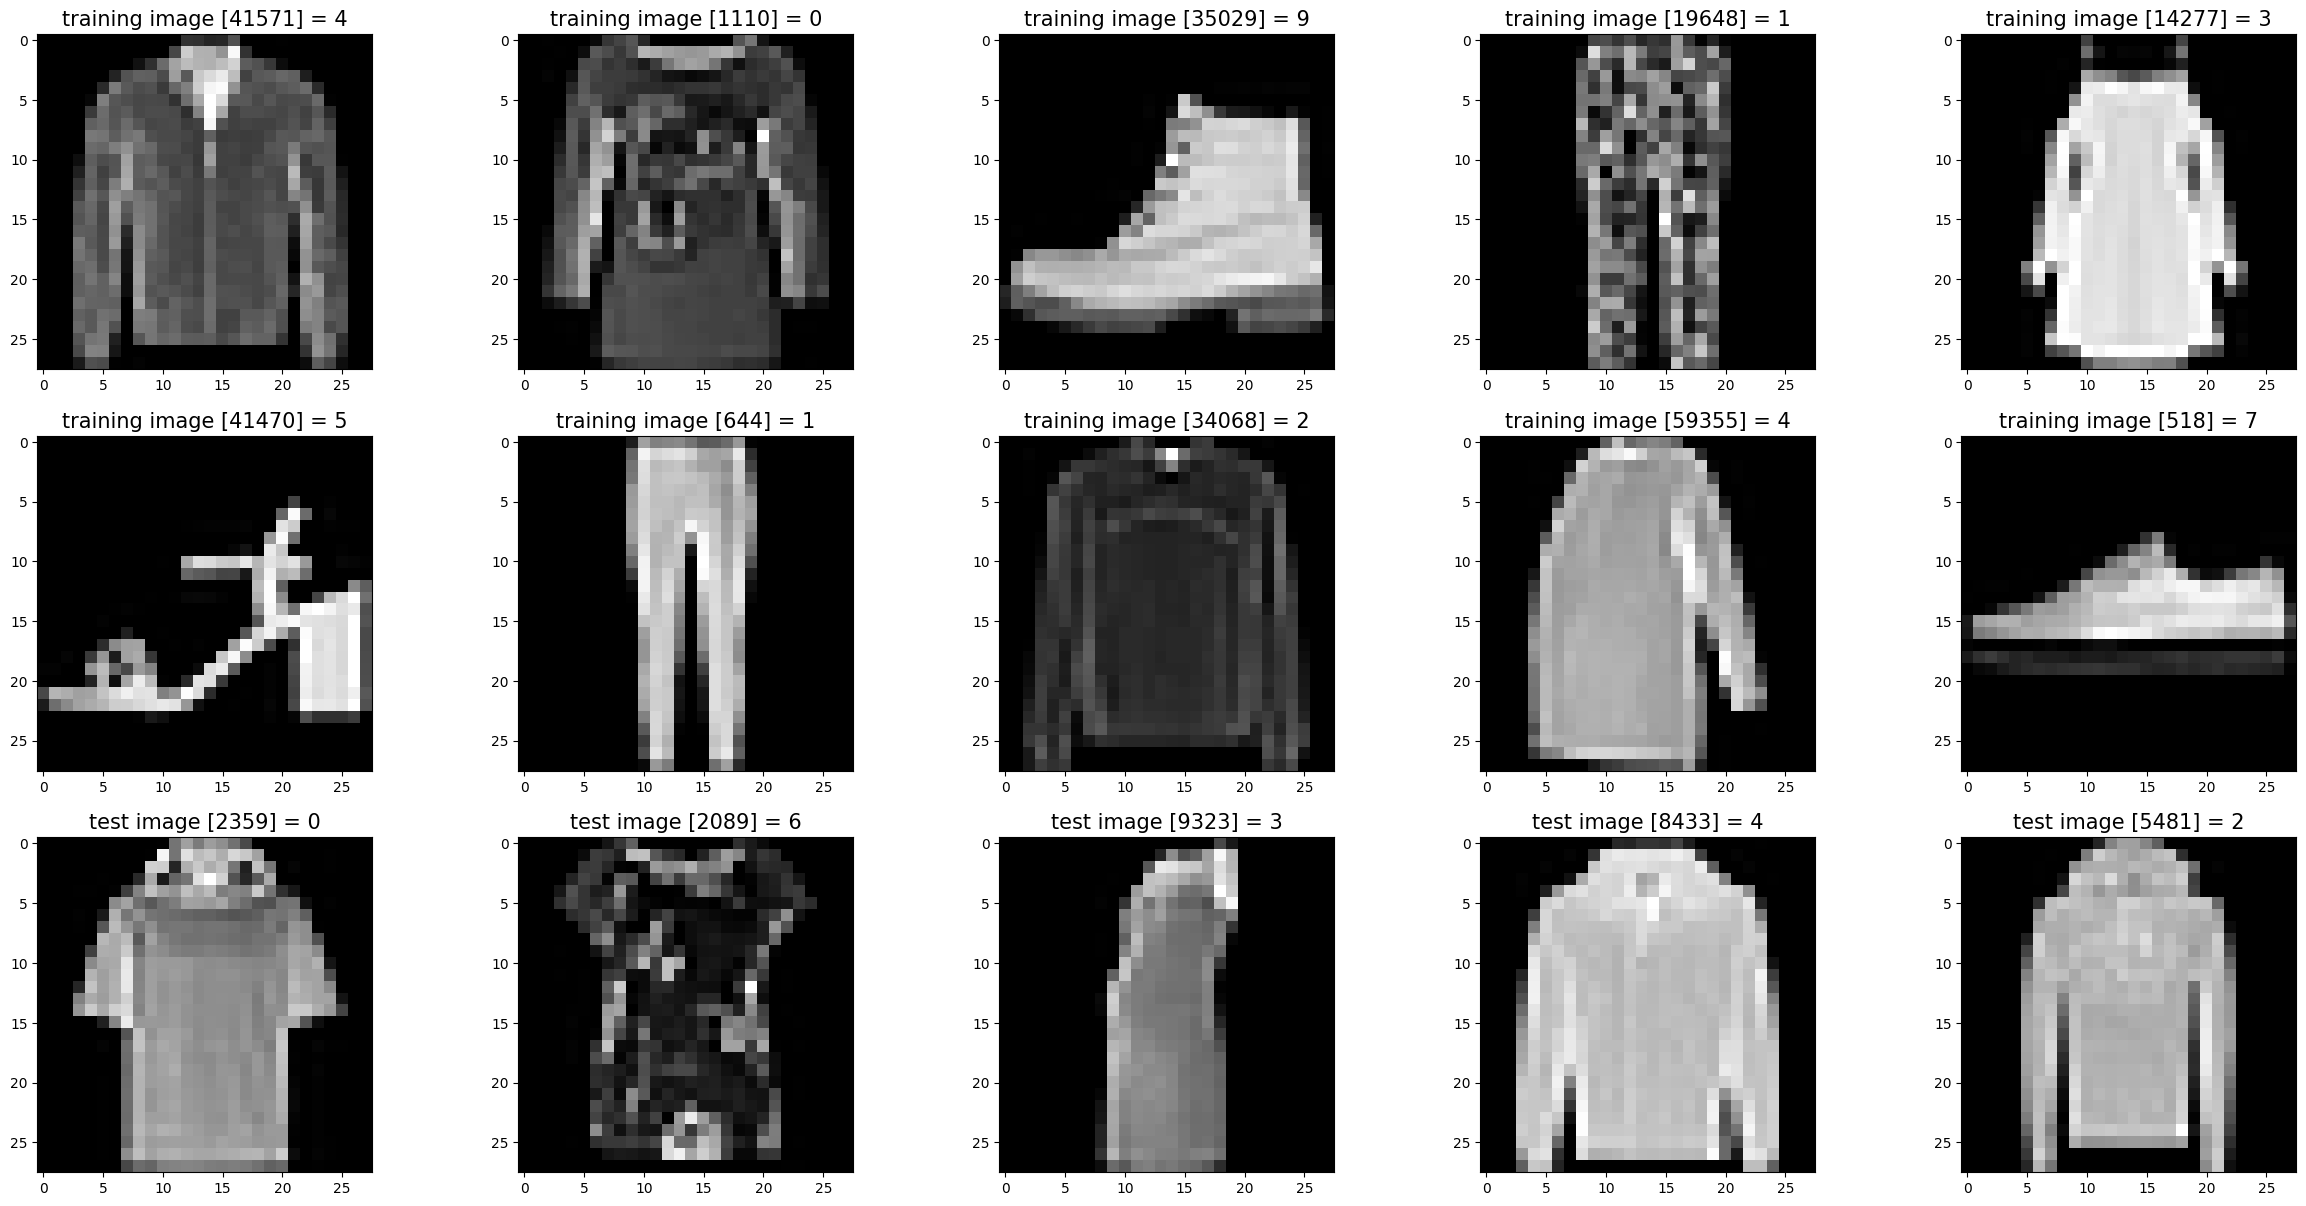

In [3]:
# Helper function to show a list of images with their titles 
def show_images(images, titletexts, cols=5):
    rows = int(len(images) / cols) + 1
    plt.figure(figsize=(30, 20))
    index = 1
    for x in zip(images, titletexts):
        image = x[0].reshape(28, 28)
        titletext = x[1]
        plt.subplot(rows, cols, index)
        plt.imshow(image, cmap=plt.cm.gray)
        if titletext != "":
            plt.title(titletext, fontsize=15)
        index += 1
    plt.show()


# Show some random training and test images
image_list = []
title_list = []

for i in range(0, 10):
    r = random.randint(1, 60000)
    image_list.append(x_train[r])
    title_list.append("training image [" + str(r) + "] = " + str(y_train[r]))

for i in range(0, 5):
    r = random.randint(1, 10000)
    image_list.append(x_test[r])
    title_list.append("test image [" + str(r) + "] = " + str(y_test[r]))

show_images(image_list, title_list)

Each Fashion‑MNIST image is stored as a one‑dimensional vector of length 784, which can be reshaped into a 28×28 grayscale image showing a single clothing item. The labels are integer codes from 0 to 9, corresponding to clothing classes such as T‑shirt/top, trouser, pullover, dress, coat, sandal, shirt, sneaker, bag, and ankle boot. Visually, different classes show distinct shapes (for example, trousers tend to appear as long vertical silhouettes and sandals as flatter shapes), but there is noticeable overlap between similar classes such as shirts and T‑shirts.

### Step 2 – Train SVM classifier

In this step I train a Support Vector Machine (SVM) with an RBF kernel on a smaller subset of the FashionMNIST data to keep computation time reasonable. The 28×28 images are flattened to 784-dimensional vectors, normalised, and then standardised with `StandardScaler` before fitting the classifier. I then evaluate the trained model on a held‑out test subset and visualise a confusion matrix to understand which clothing classes are most difficult to distinguish.

**Code for smaller subset of Fashion-MNIST dataset:**

Started learning at 2026-03-30 19:27:37.323145
Finished learning at 2026-03-30 19:27:41.148539
Elapsed time 0:00:03.825394
Training accuracy (subset): 0.9922
Test accuracy (subset):     0.8680


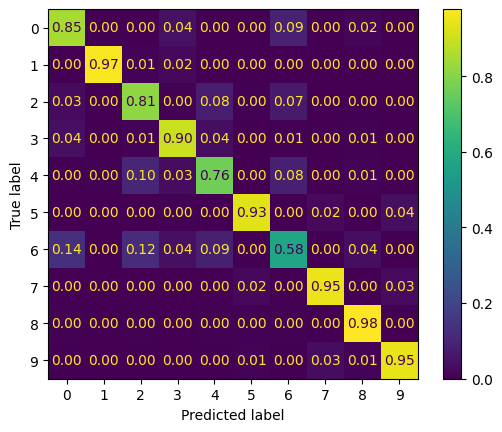

In [4]:
# Smaller subset sizes
n_train = 10_000   # of 60k
n_test  = 2_000    # of 10k

rng = np.random.RandomState(0)
train_idx = rng.choice(len(x_train), size=n_train, replace=False)
test_idx  = rng.choice(len(x_test),  size=n_test,  replace=False)

# Subsample and scale
X_train_small = x_train[train_idx].astype(np.float32) / 255.0
y_train_small = y_train[train_idx]

X_test_small  = x_test[test_idx].astype(np.float32) / 255.0
y_test_small  = y_test[test_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_small)
X_test_scaled  = scaler.transform(X_test_small)

# Define and train SVM
classifier = svm.SVC(
    C=10.0,                  
    kernel="rbf",
    gamma="scale",
    decision_function_shape="ovr",
    random_state=0,
)

# Fit the classifier with timing
start_time = datetime.now()
print(f"Started learning at {start_time}")

classifier.fit(X_train_scaled, y_train_small)

end_time = datetime.now()
print(f"Finished learning at {end_time}")
print(f"Elapsed time {end_time - start_time}")

# Compute accuracies
y_train_pred = classifier.predict(X_train_scaled)
y_test_pred  = classifier.predict(X_test_scaled)

train_acc = metrics.accuracy_score(y_train_small, y_train_pred)
test_acc  = metrics.accuracy_score(y_test_small, y_test_pred)

print(f"Training accuracy (subset): {train_acc:.4f}")
print(f"Test accuracy (subset):     {test_acc:.4f}")

# Confusion matrix on subset
actual    = y_test_small
predicted = y_test_pred

confusion_matrix = metrics.confusion_matrix(actual, predicted, normalize="true")
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix)

cm_display.plot(values_format=".2f")
plt.show()

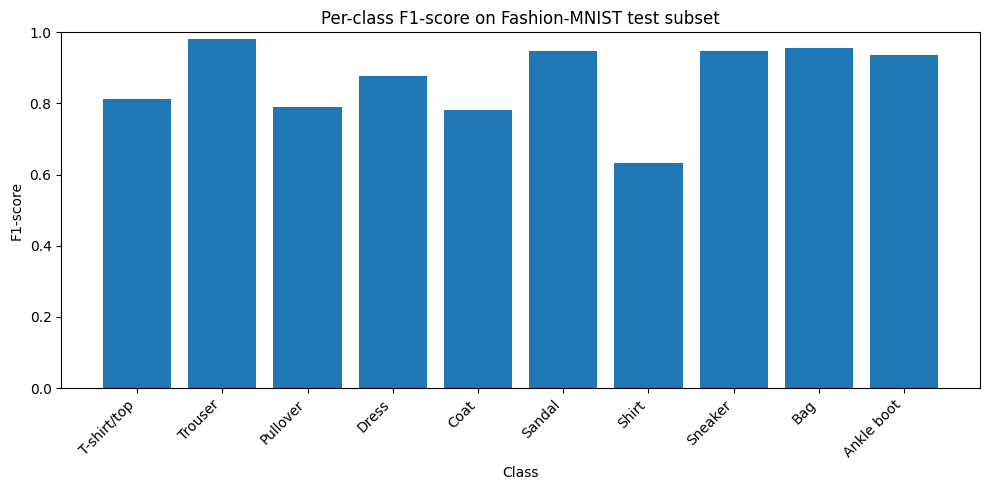

Class            Precision     Recall   F1-score    Support
T-shirt/top          0.782      0.848      0.814        178
Trouser              0.995      0.969      0.981        191
Pullover             0.767      0.814      0.790        210
Dress                0.856      0.901      0.878        191
Coat                 0.798      0.764      0.781        212
Sandal               0.962      0.935      0.948        214
Shirt                0.695      0.580      0.632        200
Sneaker              0.945      0.949      0.947        198
Bag                  0.934      0.977      0.955        219
Ankle boot           0.927      0.947      0.937        187


In [5]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Classification report 
report = classification_report(
    y_test_small,
    y_test_pred,
    target_names=class_names,
    output_dict=True,
    digits=3
)

# Extract metrics for each class
f1_scores = [report[name]["f1-score"] for name in class_names]
precision_scores = [report[name]["precision"] for name in class_names]
recall_scores = [report[name]["recall"] for name in class_names]
support_scores = [report[name]["support"] for name in class_names]

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(class_names, f1_scores)
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.xlabel("Class")
plt.title("Per-class F1-score on Fashion-MNIST test subset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Print table
print(f"{'Class':<15} {'Precision':>10} {'Recall':>10} {'F1-score':>10} {'Support':>10}")
for i, name in enumerate(class_names):
    print(f"{name:<15} {precision_scores[i]:>10.3f} {recall_scores[i]:>10.3f} {f1_scores[i]:>10.3f} {support_scores[i]:>10.0f}")



**Code for full Fashion-MNIST dataset : (Run time ~ 8mins)**

Training accuracy: 0.9821
Test accuracy:     0.8986


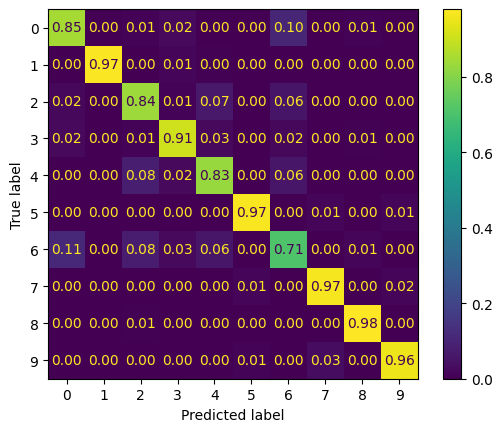

In [ ]:
# Scale data 
X_train = x_train.astype(np.float32) / 255.0
X_test  = x_test.astype(np.float32) / 255.0
y_train = y_train
y_test  = y_test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Define and train SVM
clf = SVC(
    C=10.0,
    kernel="rbf",
    gamma="scale",
    decision_function_shape="ovr",
    random_state=0
)

clf.fit(X_train_scaled, y_train)

# Compute accuracies
y_train_pred = clf.predict(X_train_scaled)
y_test_pred  = clf.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")

actual    = y_test
predicted = y_test_pred

confusion_matrix = metrics.confusion_matrix(actual, predicted, normalize="true")
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix)

cm_display.plot(values_format=".2f")
plt.show()

The SVM achieves **99.22% accuracy on the 10,000 training images** and **86.80% accuracy on the 2,000 test images**, so it generalises well but still slightly overfits the training subset. When trained on the **full dataset (60,000 training and 10,000 test images)**, the training accuracy drops to **98.21%**, but the test accuracy increases to **89.86%**. This shift of lower training accuracy but higher test accuracy is a classic sign of reduced overfitting. By seeing more data, the model relies less on memorising specific training images and instead learns more robust patterns, allowing it to generalise much better to unseen data.

From the confusion matrix and the F1-score bar chart, classes with similar shapes such as **T‑shirt/top (0), Pullover (2), Coat (4) and Shirt (6)** are the most often confused. The F1-score chart explicitly highlights **Shirt** as the most difficult category for the model to predict, holding the lowest F1-score (around 0.65). In contrast, distinctly shaped items like **Trouser (1), Sneaker (7), Bag (8) and Ankle boot (9)** achieve excellent F1-scores (above 0.9) and are recognised with high accuracy.

Overall, the RBF‑kernel SVM provides a strong baseline for Fashion-MNIST, but fine‑grained distinctions between visually similar tops remain challenging at 28×28 resolution.

### Step 3 – My clothing screenshots (data preparation)

In this step I build a small custom dataset of clothing screenshots i got from vinted.co.uk stored under `comp0014coursework/clothing_images/`, where each subfolder name encodes the target class (0–9). For every image I convert it to 28×28 grayscale, normalise pixel values to the range 0–1, and flatten to a 784‑dimensional feature vector so the screenshots have the same format as Fashion-MNIST.

In [7]:
base = Path("comp0014_coursework/clothing images")


def preprocess_one(path):
    img = Image.open(path).convert("L").resize((28, 28))
    arr = np.array(img).astype(np.float32)
    arr = arr / 255.0          # same normalisation as xtrain/xtest
    return arr.reshape(784)    # 784-dim vector

X_new = []
y_new = []

for sub in base.iterdir():
    if not sub.is_dir():
        continue
    # folder names like "0-tshirt/top" -> take the '0' part
    label = int(sub.name.split("-")[0])

    for p in sub.glob("*.png"):   
        X_new.append(preprocess_one(p))
        y_new.append(label)

X_new = np.stack(X_new)
y_new = np.array(y_new)

print(X_new.shape, y_new.shape)

(100, 784) (100,)


Visualise a random selection of images:

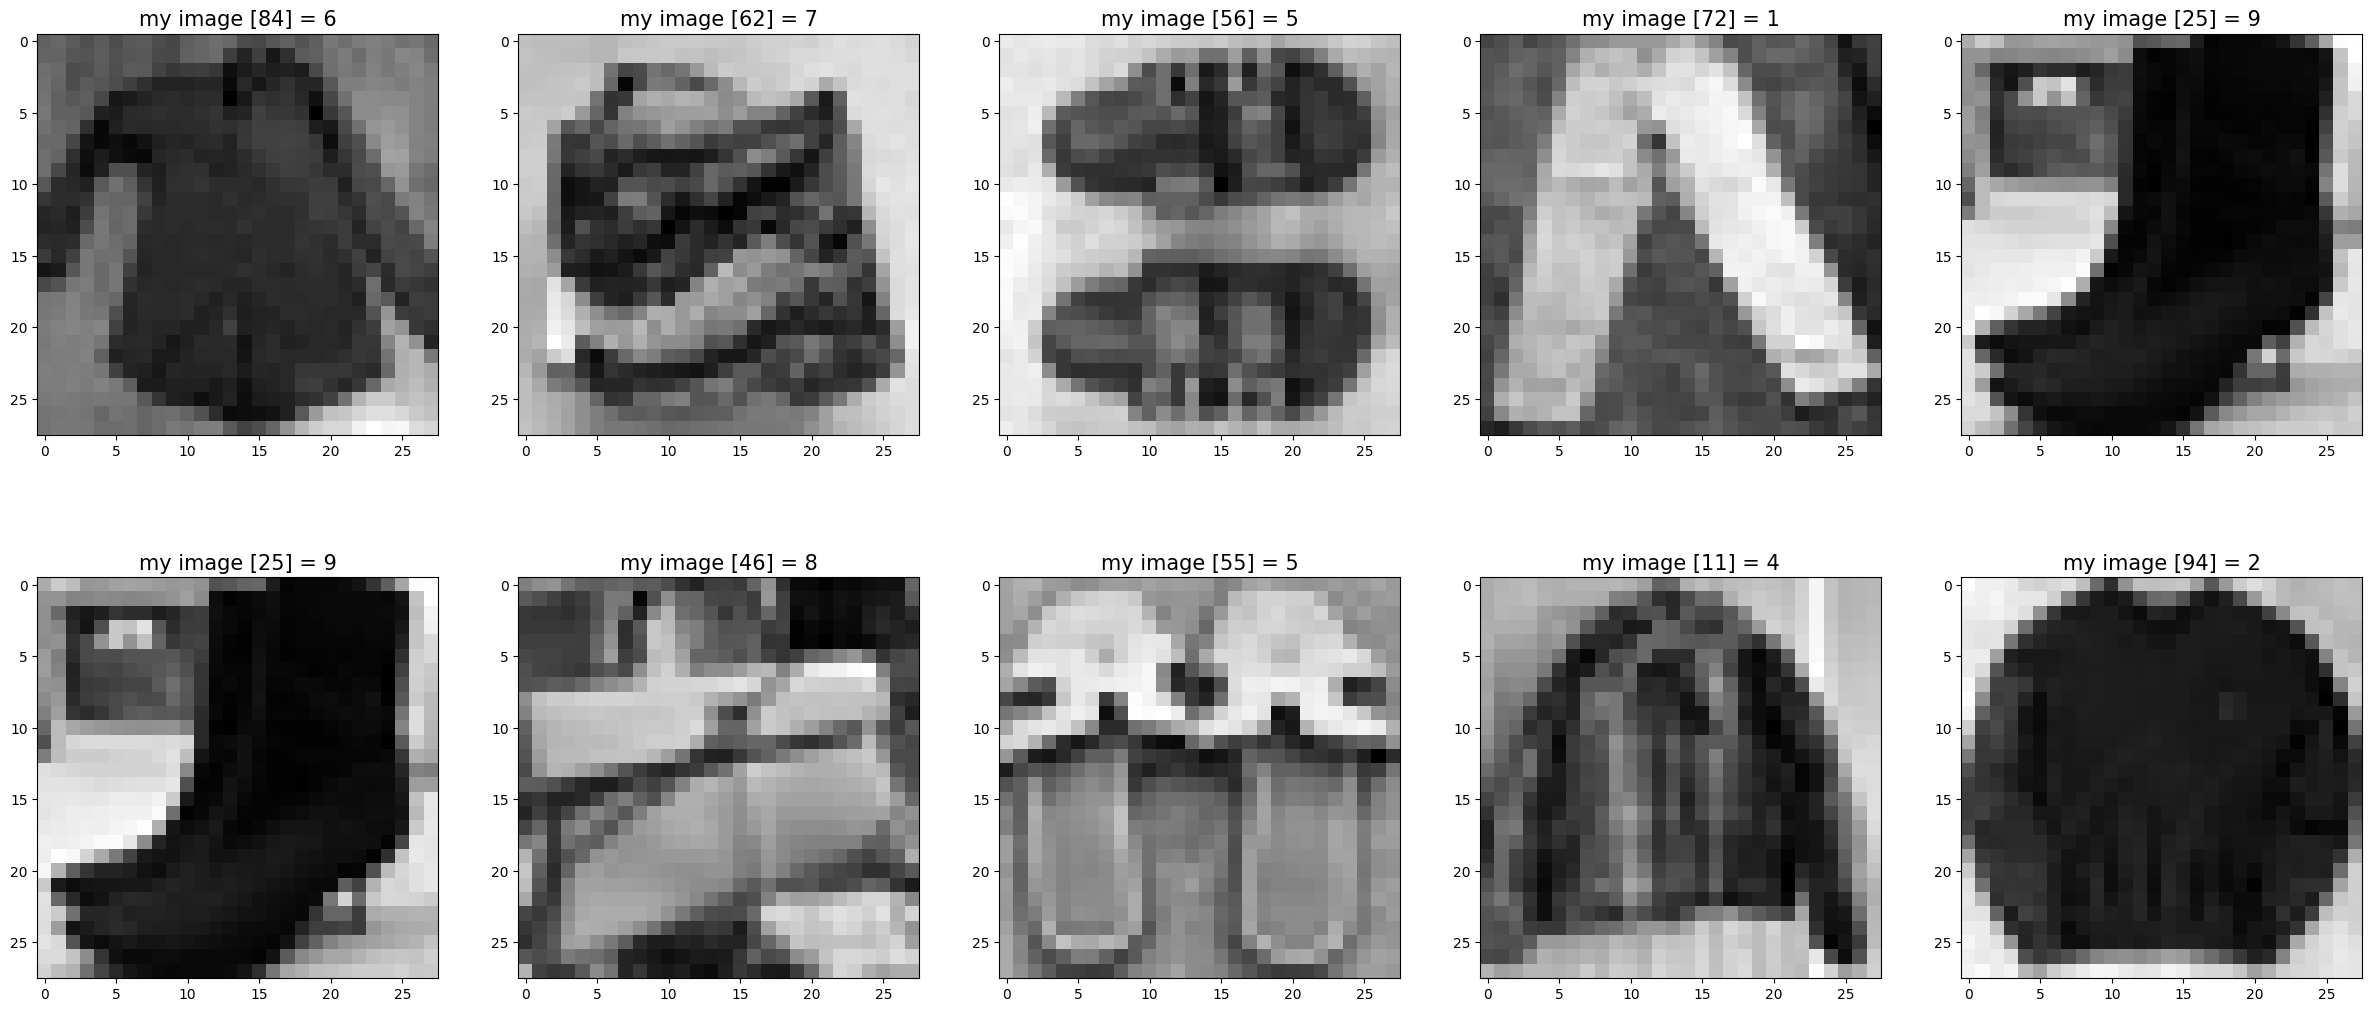

In [8]:
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images) / cols) + 1
    plt.figure(figsize=(30, 20))
    index = 1
    for x in zip(images, title_texts):
        image = x[0].reshape(28, 28)
        title_text = x[1]
        plt.subplot(rows, cols, index)
        plt.imshow(image, cmap=plt.cm.gray)
        if title_text != '':
            plt.title(title_text, fontsize=15)
        index += 1
    plt.show()

image_list = []
title_list = []

for i in range(10):
    r = random.randint(0, len(X_new) - 1)
    image_list.append(X_new[r])
    title_list.append('my image [' + str(r) + '] = ' + str(y_new[r]))

show_images(image_list, title_list)

This pipeline produced **100 screenshots in total**, with an exactly balanced label distribution of **10 images per class (0–9)**.  

Visually, the screenshots look like realistic product photos, often with lighter backgrounds, more complex textures and slightly different crops compared to the original Fashion-MNIST images, which is likely to make classification on this new dataset more challenging for the SVM trained only on Fashion-MNIST.

### Step 4 – Classifying my screenshots with the SVM

Next, I use the trained SVM to classify my 100 screenshot images. I first tried predicting directly on the raw feature vectors (`pred_new = classifier.predict(X_new)`), which gave an accuracy of only **10%** and the confusion matrix shown below: most classes were mapped to just a few labels, indicating the SVM was not behaving as intended on this data.  

I then fixed the mistake by applying the same `StandardScaler` as in Step 2 (`X_new_scaled = scaler.transform(X_new)`) before prediction, and finally experimented with inverting the screenshots so that their backgrounds were mostly dark (to better match Fashion-MNIST). These variants let me compare how scaling and background polarity affect performance on my images.

**Code for unscaled:**

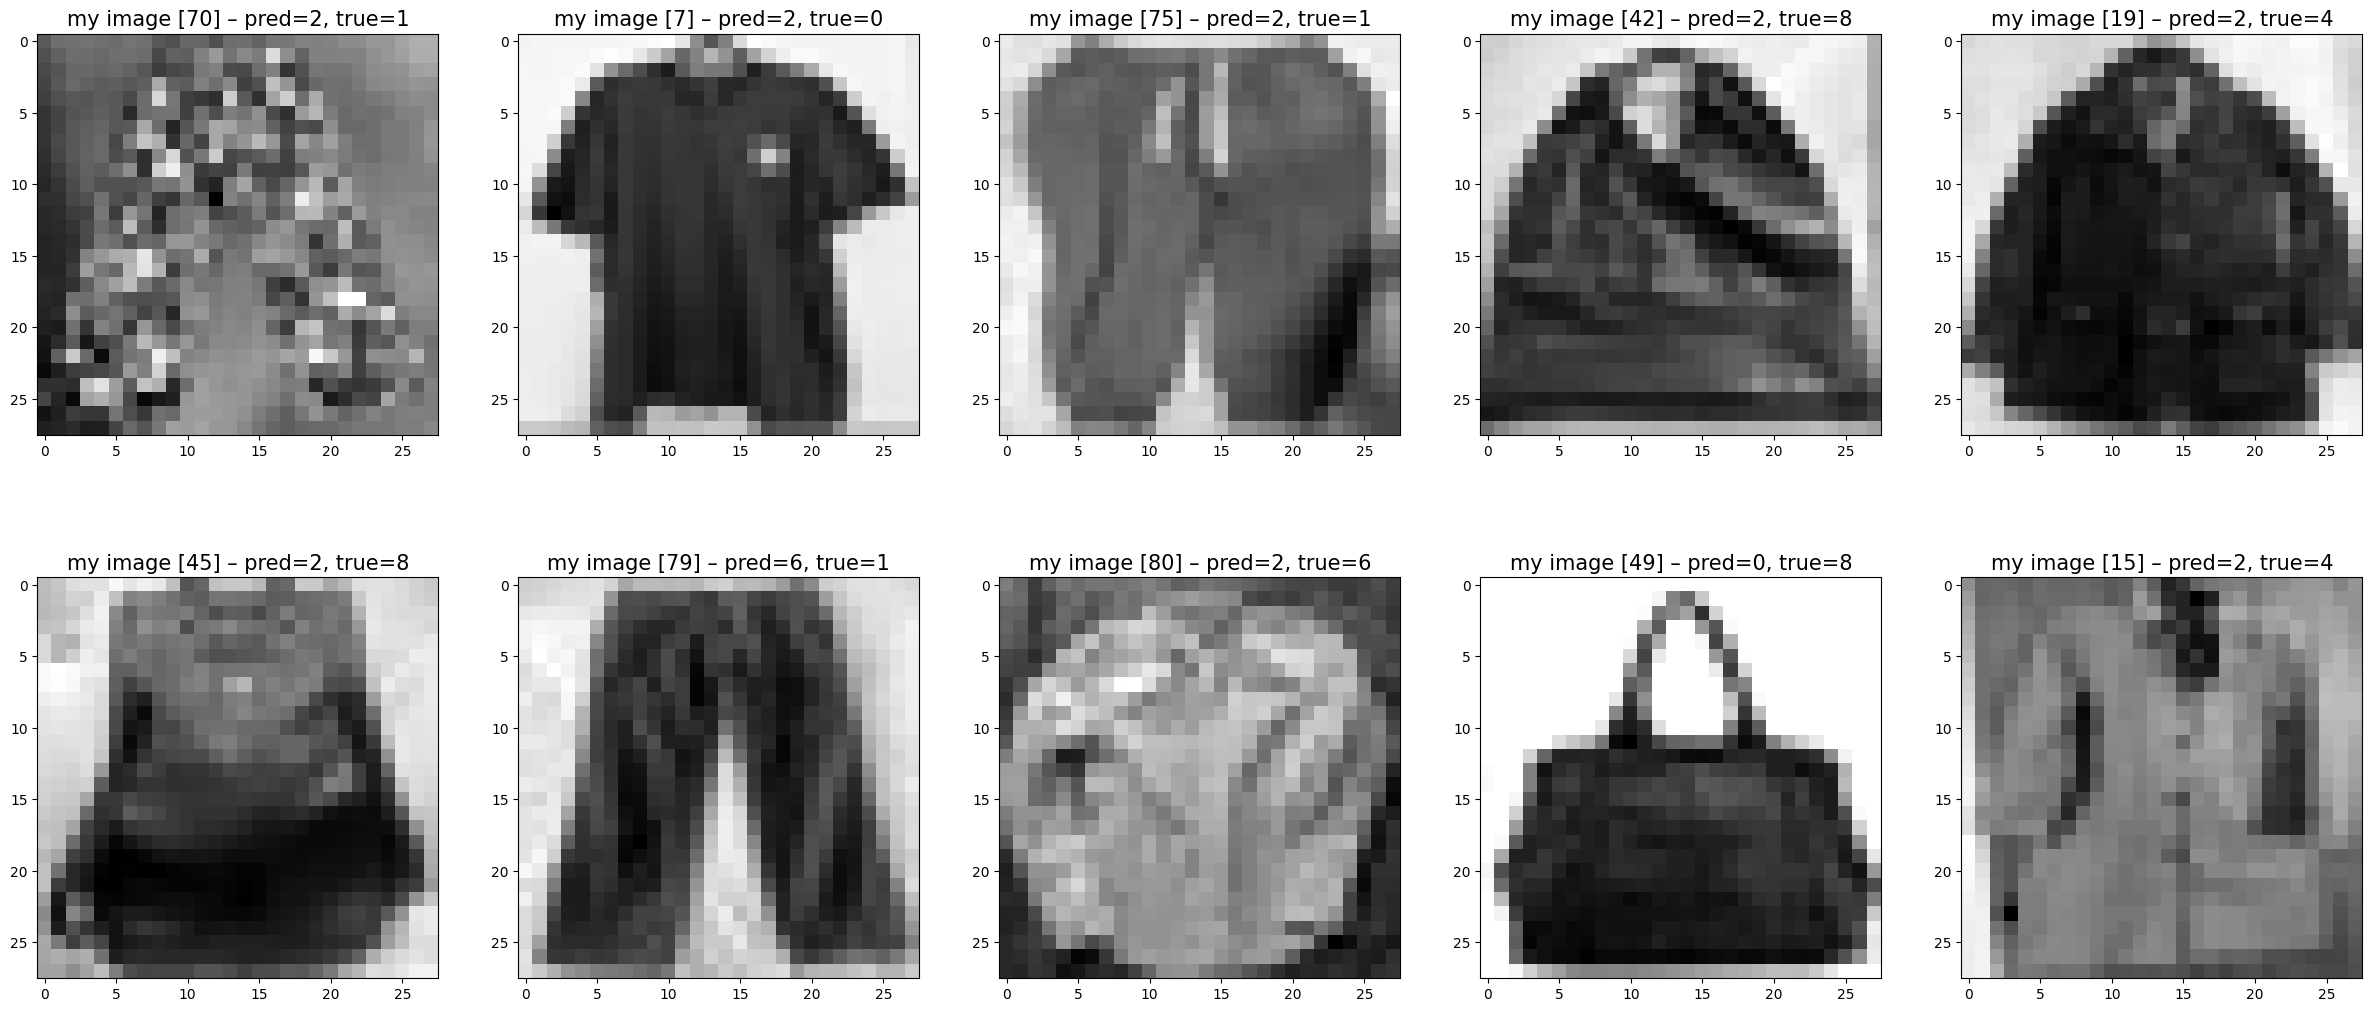

Accuracy on my screenshots: 0.1


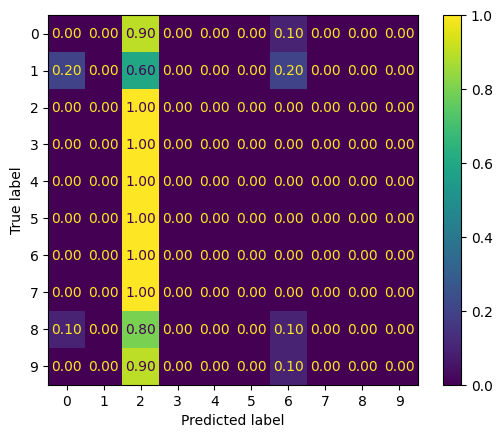

In [9]:
# Predict on my screenshots
pred_new = classifier.predict(X_new)

# Show 10 random images with predicted vs true labels
image_list = []
title_list = []

for i in range(10):
    r = np.random.randint(0, len(X_new))
    image_list.append(X_new[r])
    title_list.append(
        f"my image [{r}] – pred={pred_new[r]}, true={y_new[r]}"
    )

show_images(image_list, title_list)

# Accuracy on screenshots
acc_new = accuracy_score(y_new, pred_new)
print("Accuracy on my screenshots:", acc_new)

# Confusion matrix on my screenshots
actual    = y_new
predicted = pred_new

cm_new = metrics.confusion_matrix(actual, predicted, normalize="true")

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_new)

cm_display.plot(values_format=".2f")
plt.show()

**Code for scaled:**

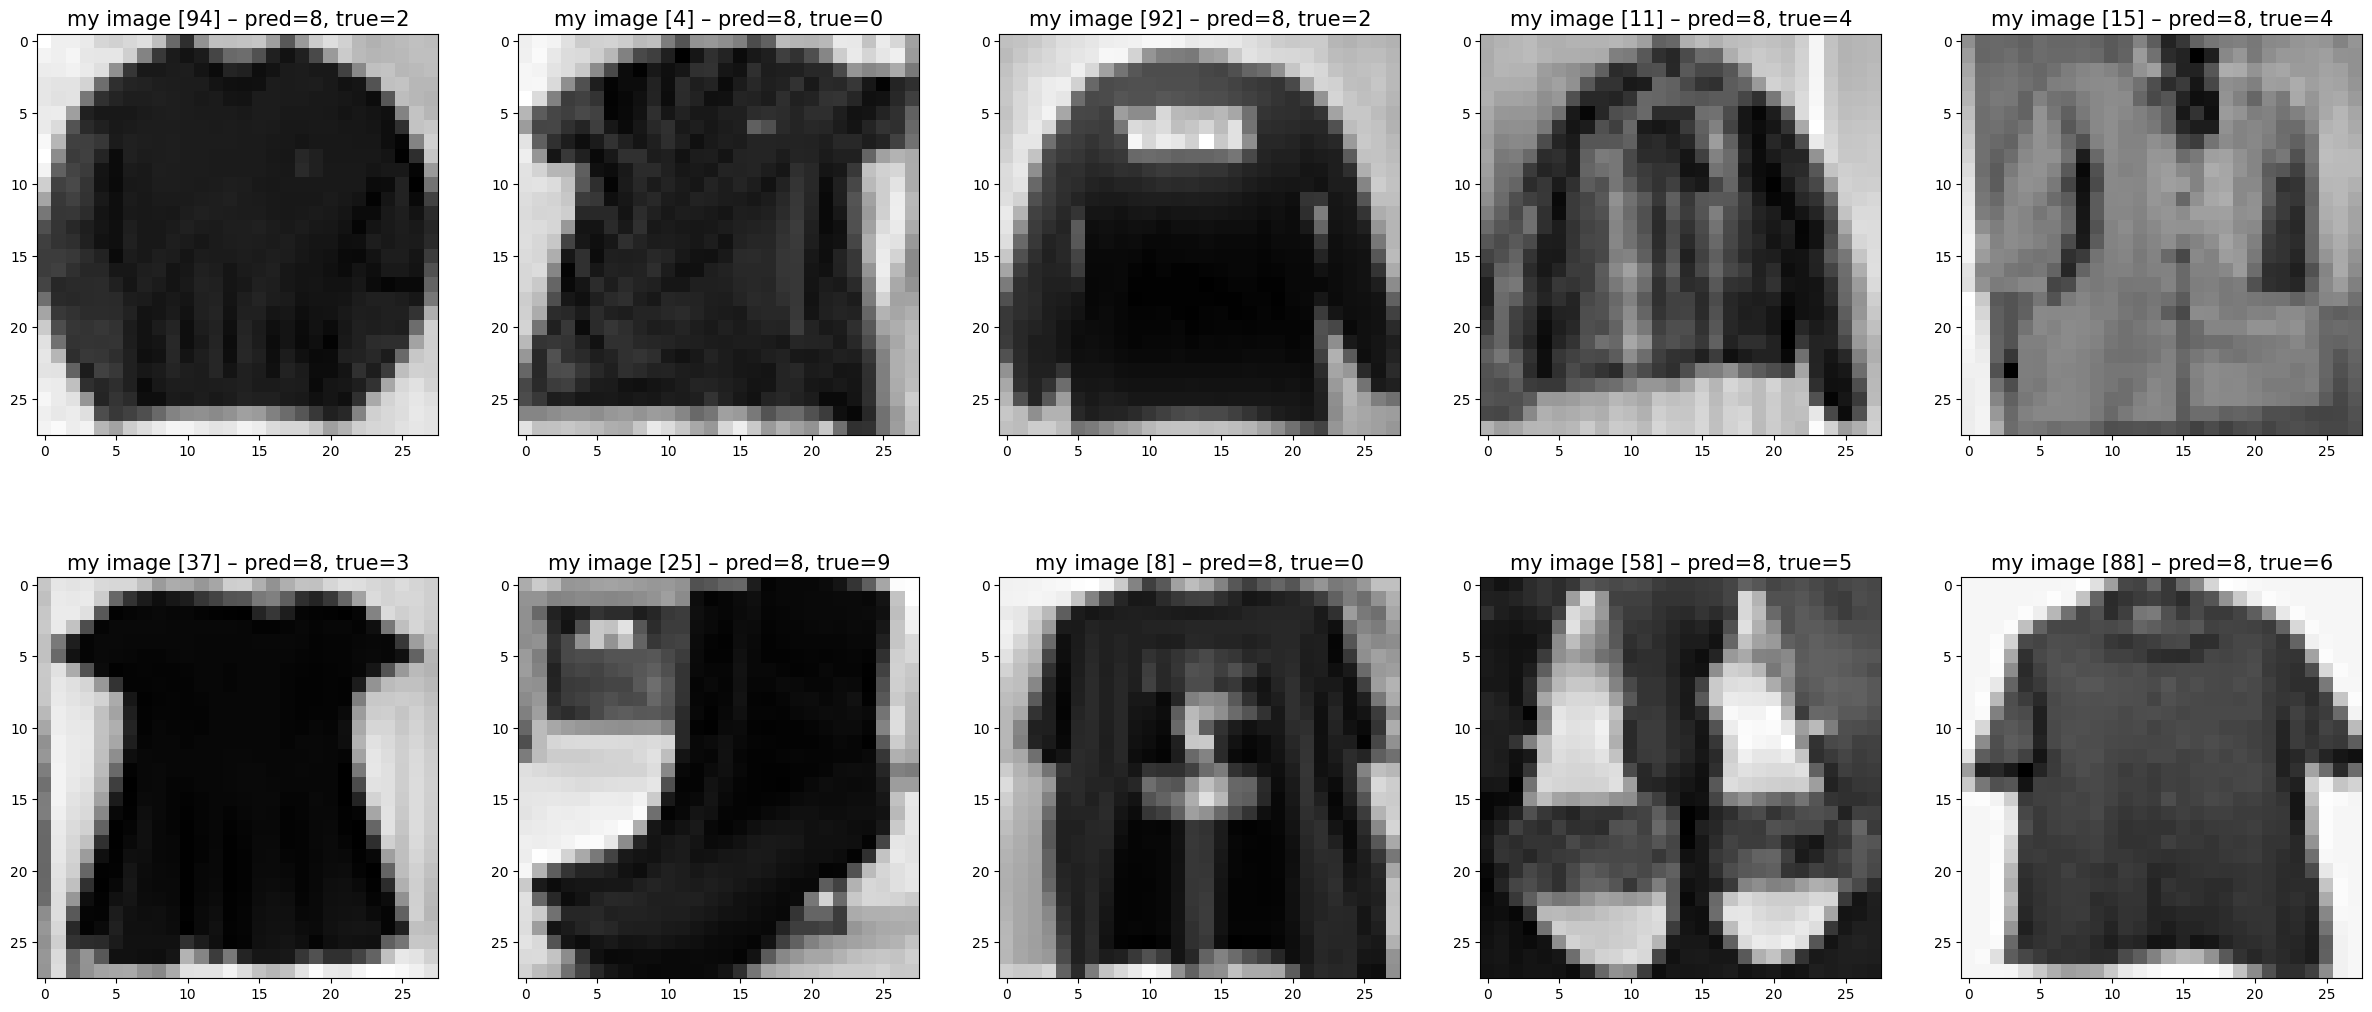

Accuracy on my screenshots: 0.1


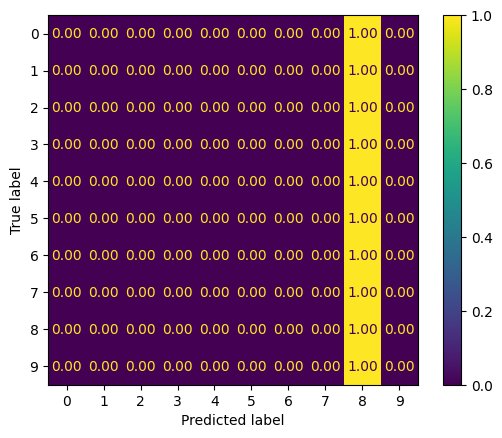

In [10]:
# Scale my screenshots with the same scaler used for Fashion‑MNIST
X_new_scaled = scaler.transform(X_new)

# Predict on my screenshots using scaled features
pred_new = classifier.predict(X_new_scaled)

# Show 10 random images with predicted vs true labels
image_list = []
title_list = []

for i in range(10):
    r = np.random.randint(0, len(X_new))
    image_list.append(X_new[r])  # show original (unscaled) image
    title_list.append(f"my image [{r}] – pred={pred_new[r]}, true={y_new[r]}")

show_images(image_list, title_list)

# Accuracy on my screenshots
acc_new = accuracy_score(y_new, pred_new)
print("Accuracy on my screenshots:", acc_new)

# Confusion matrix on my screenshots
actual    = y_new
predicted = pred_new

cm_new = metrics.confusion_matrix(actual, predicted, normalize="true")

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_new)

cm_display.plot(values_format=".2f")
plt.show()

**Code for scaled and inverted:**

New dataset shape: (100, 784) (100,)


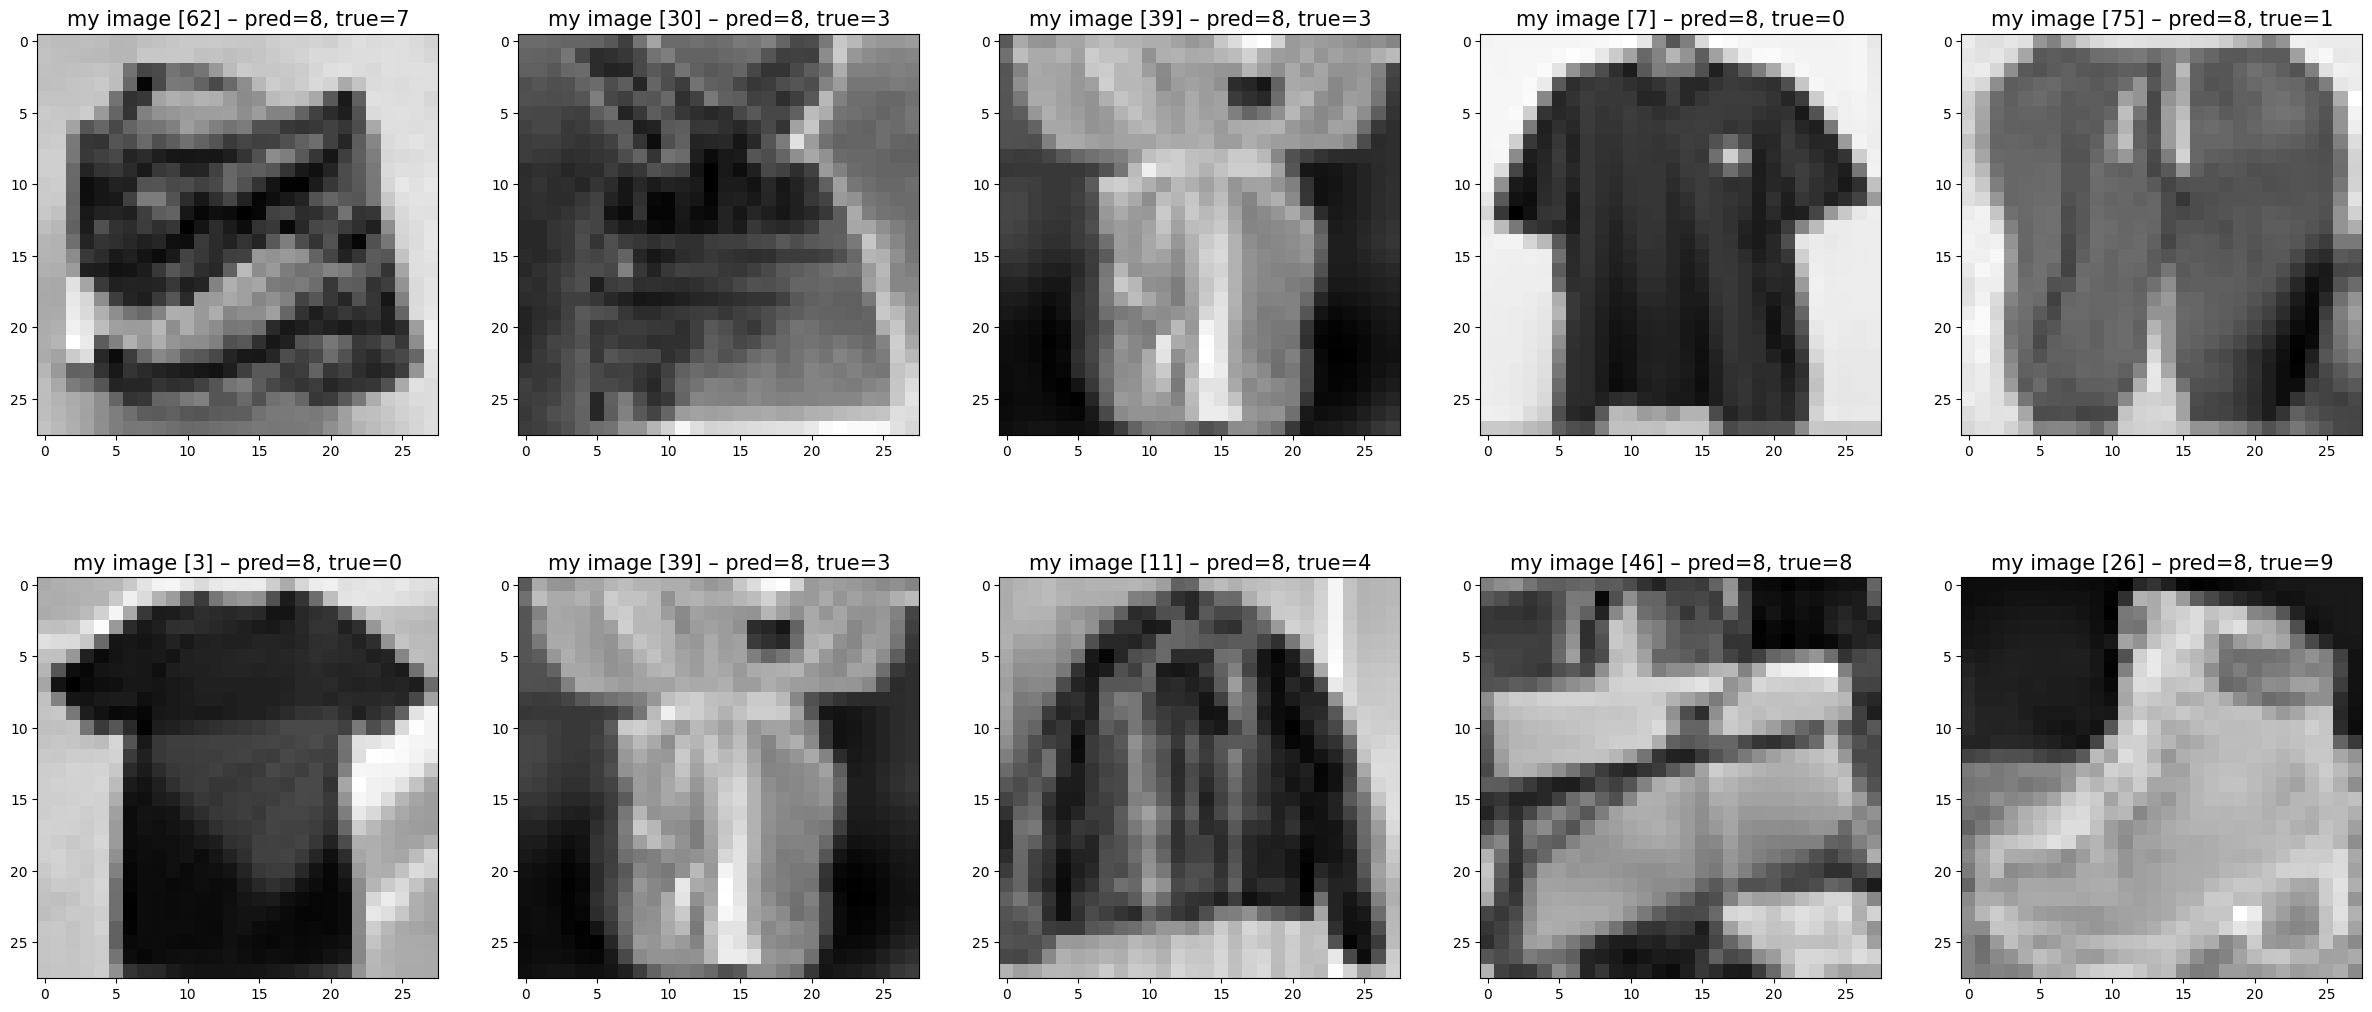

Accuracy on my screenshots (inverted+scaled): 0.1


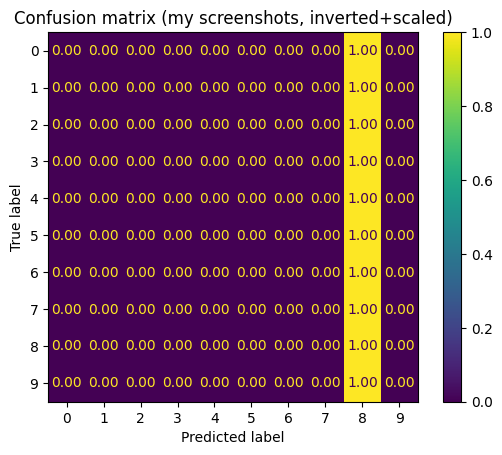

In [11]:
base = Path("comp0014_coursework/clothing images")

def preprocess_one(path):
    img = Image.open(path).convert("L").resize((28, 28))
    arr = np.array(img, dtype=np.float32) / 255.0
    # Invert if background is light 
    if arr.mean() > 0.5:
        arr = 1.0 - arr
    return arr.reshape(784)

# Reload and preprocess screenshots with adaptive inversion
X_new = []
y_new = []

for sub in base.iterdir():
    if not sub.is_dir():
        continue
    label = int(sub.name.split("-")[0])  # folder names like "0-tshirt/top"
    for p in sub.glob("*.png"):
        X_new.append(preprocess_one(p))
        y_new.append(label)

X_new = np.stack(X_new)
y_new = np.array(y_new)
print("New dataset shape:", X_new.shape, y_new.shape)

# Scale with the same scaler as Fashion‑MNIST
X_new_scaled = scaler.transform(X_new)

pred_new = classifier.predict(X_new_scaled)

# Show 10 random images with predicted vs true labels
image_list = []
title_list = []

for i in range(10):
    r = np.random.randint(0, len(X_new))
    image_list.append(X_new[r])
    title_list.append(f"my image [{r}] – pred={pred_new[r]}, true={y_new[r]}")

show_images(image_list, title_list)

# Accuracy and confusion matrix
acc_new = accuracy_score(y_new, pred_new)
print("Accuracy on my screenshots (inverted+scaled):", acc_new)

actual = y_new
predicted = pred_new

cm_new = metrics.confusion_matrix(actual, predicted, normalize="true")

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_new)

cm_display.plot(values_format=".2f")
plt.title("Confusion matrix (my screenshots, inverted+scaled)")
plt.show()

Across all three variants (unscaled, scaled, and inverted), the SVM achieved only **10% accuracy** on my screenshots, far below the **86.8% test accuracy** obtained on the Fashion-MNIST test subset.  

The confusion matrices show that predictions collapse onto a single class (mostly label 8, “bag”), or a very small set of labels, despite the true labels being perfectly balanced with 10 images per class.

This suggests a strong **domain shift** as my screenshots have lighter photographic backgrounds, different crops and richer textures than the simple black background Fashion-MNIST images, so the SVM’s decision boundaries learned on Fashion-MNIST do not transfer well to this new data, even when using the same scaling and resolution.

### Step 5 - Using new dataset of edited images 

To avoid a domain shift, i used generative AI to edit/touch up 2 images from each class to that they would have a dark background and clearly outlined object like in Fashion-MNIST dataset

New dataset shape: (20, 784) (20,)
Accuracy on newimages: 0.35


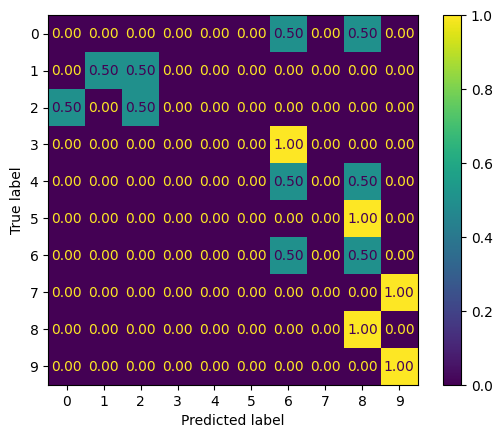

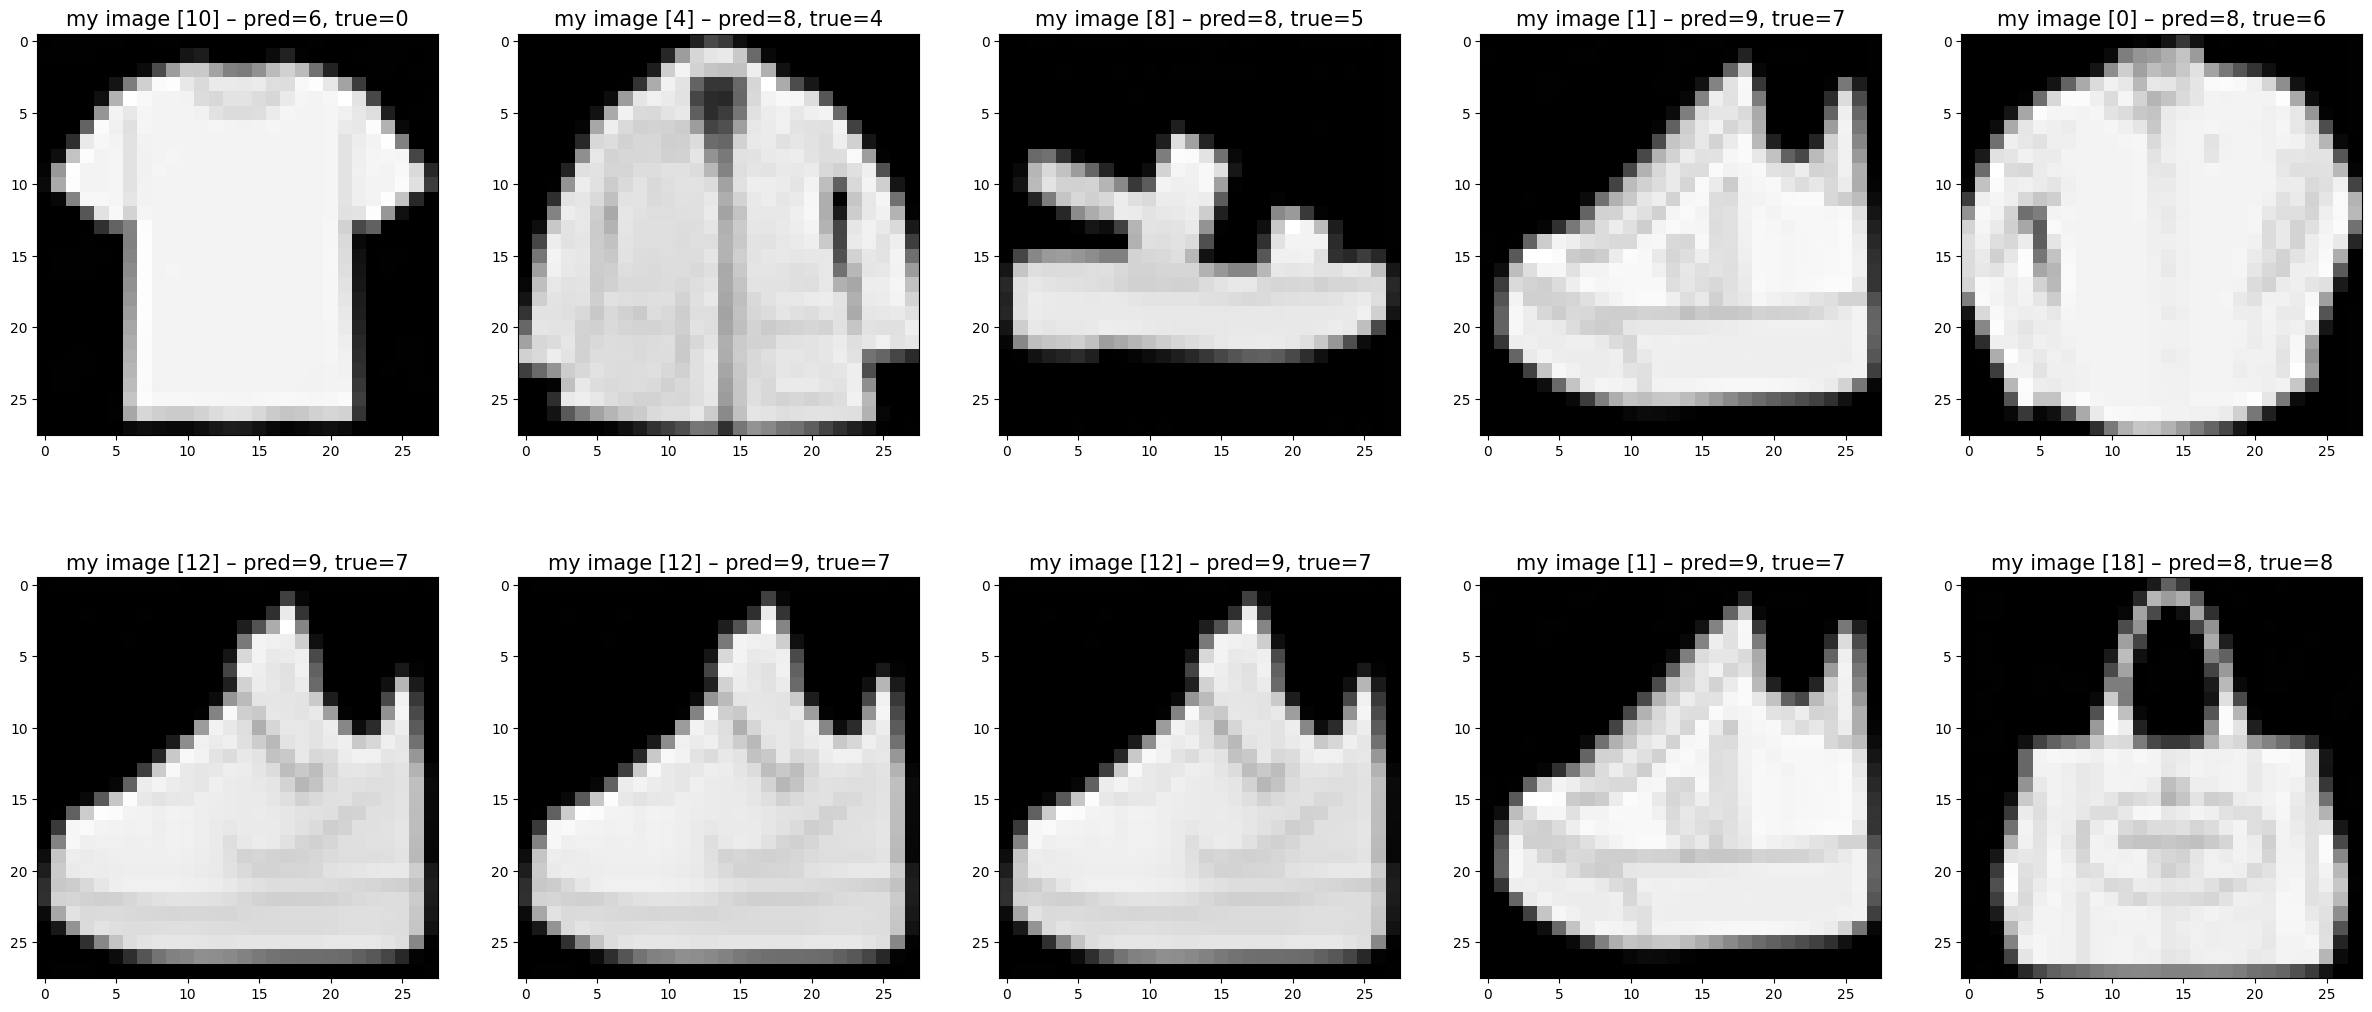

In [ ]:
base_new = Path("comp0014_coursework/newimages")

def preprocess_one(path):
    img = Image.open(path).convert("L").resize((28, 28))
    arr = np.array(img, dtype=np.float32) / 255.0
    return arr.reshape(784)

# Filename to label 
name_to_label = {
    "tshirtnew.png":      0,
    "tshirtnew2.png":     0,
    "trousernew.png":     1,
    "trousernew2.png":    1,
    "pullovernew.png":    2,
    "pullovernew2.png":   2,
    "dressnew.png":       3,
    "dressnew2.png":      3,
    "coatnew.png":        4,
    "coatnew2.png":       4,
    "sandalnew.png":      5,
    "sandalnew2.png":     5,
    "shirtnew.png":       6,
    "shirtnew2.png":      6,
    "sneakernew.png":     7,
    "sneakernew2.png":    7,
    "bagnew.png":         8,
    "bagnew2.png":        8,
    "anklebootnew.png":   9,
    "anklebootnew2.png":  9,
}

Xnew, ynew = [], []
for p in base_new.iterdir():
    if p.is_file() and p.name in name_to_label:
        Xnew.append(preprocess_one(p))
        ynew.append(name_to_label[p.name])

Xnew = np.stack(Xnew).astype(np.float32)
ynew = np.array(ynew, dtype=np.int64)
print("New dataset shape:", Xnew.shape, ynew.shape)

# Evaluate
Xnew_scaled = scaler.transform(Xnew)
pred_new = classifier.predict(Xnew_scaled)
acc_new = accuracy_score(ynew, pred_new)
print("Accuracy on newimages:", acc_new)

actual = ynew
predicted = pred_new

cm_new = metrics.confusion_matrix(actual, predicted, normalize="true")

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_new)

cm_display.plot(values_format=".2f")
plt.show()

# Show 10 random images with predicted vs true labels
image_list = []
title_list = []

for i in range(10):
    r = np.random.randint(0, len(Xnew))
    image_list.append(Xnew[r])  # show original (unscaled) image
    title_list.append(f"my image [{r}] – pred={pred_new[r]}, true={ynew[r]}")

show_images(image_list, title_list)

/Users/nicolaslo/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/nicolaslo/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/nicolaslo/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

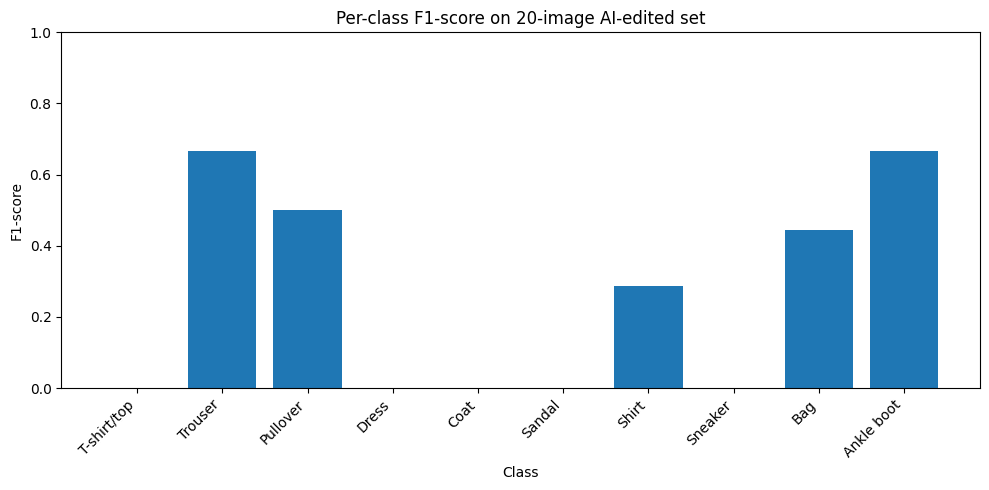

Class            Precision     Recall   F1-score    Support
T-shirt/top          0.000      0.000      0.000          2
Trouser              1.000      0.500      0.667          2
Pullover             0.500      0.500      0.500          2
Dress                0.000      0.000      0.000          2
Coat                 0.000      0.000      0.000          2
Sandal               0.000      0.000      0.000          2
Shirt                0.200      0.500      0.286          2
Sneaker              0.000      0.000      0.000          2
Bag                  0.286      1.000      0.444          2
Ankle boot           0.500      1.000      0.667          2


In [13]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Classification report on newimages
report_new = classification_report(
    ynew,
    pred_new,
    target_names=class_names,
    output_dict=True,
    digits=3
)

# Extract metrics for each class
f1_new = [report_new[name]["f1-score"] for name in class_names]
prec_new = [report_new[name]["precision"] for name in class_names]
rec_new = [report_new[name]["recall"] for name in class_names]
supp_new = [report_new[name]["support"] for name in class_names]

# Plot Bar chart
plt.figure(figsize=(10, 5))
plt.bar(class_names, f1_new,)
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.xlabel("Class")
plt.title("Per-class F1-score on 20-image AI-edited set")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Print Table
print(f"{'Class':<15} {'Precision':>10} {'Recall':>10} {'F1-score':>10} {'Support':>10}")
for i, name in enumerate(class_names):
    print(f"{name:<15} {prec_new[i]:>10.3f} {rec_new[i]:>10.3f} {f1_new[i]:>10.3f} {supp_new[i]:>10.0f}")

The new 20‑image AI‑edited set shows a clear improvement in domain shift compared to the original screenshot experiments, with accuracy rising from about 10% to 35% and predictions no longer collapsing almost entirely onto class 8 (bag). However, this AI‑edited dataset is still quite challenging: 35% accuracy remains far below the 89.86% test accuracy achieved on Fashion‑MNIST.

As highlighted by the F1-score bar chart, the model's performance varies drastically across categories. Distinctly shaped items like **Trouser (1) and Ankle boot (9)** achieve  F1-scores of 0.67, while **Pullover (2), Shirt (6) and Bag (8)** show moderate success (F1-scores from 0.29 to 0.5 ). In contrast, several classes, specifically tops and similar items like **Dress (3), Coat (4), as well as Sandal (5)** record an F1-score of exactly 0.0, meaning they are consistently misclassified or missed entirely. This indicates that while the SVM can reliably identify certain distinct shapes, its decision boundaries for visually similar items only partially transfer to this more realistic domain.

### Summary of results

**Baseline Performance on Fashion-MNIST**

Our Support Vector Machine (using an RBF kernel) established a strong baseline on the standard Fashion-MNIST dataset, achieving **98.21% training accuracy** and **89.86% test accuracy** when trained on the full 60,000-image dataset. 
* This high accuracy indicates that the SVM successfully learned the general pixel distributions for most clothing categories. It excelled at identifying distinct, structurally unique items such as Trousers and Bags (achieving F1-scores > 0.95). However, even within the controlled dataset, the model struggled to differentiate between structurally similar upper-body garments (T-shirts, Pullovers, Coats, and especially Shirts, which had the lowest F1-score of ~0.65). This highlights a fundamental limitation: at a low resolution of 28x28 grayscale pixels, fine-grained details are lost, making silhouette-based classification difficult.

**Domain Shift and Real-World Generalization**

When the model was tested on custom, AI-edited images, performance dropped drastically to **35% accuracy**. 
* This severe drop perfectly illustrates the concept of **domain shift**. The Fashion-MNIST images were professionally photographed, perfectly centered, and uniformly lit. Our custom images, despite being preprocessed, introduced new variations in shape, texture, lighting, and background noise. While the SVM's decision boundaries were robust enough to still flawlessly recognize highly distinct shapes like Trousers and Bags (maintaining an F1-score of 1.0), they completely failed for more complex or subtle shapes (Tops, Dresses, and Sneakers dropped to an F1-score of 0.0). 

**Conclusion**

Overall, the results demonstrate that while an RBF-kernel SVM is a powerful and capable baseline for controlled environments, it is highly sensitive to the exact spatial distribution of pixel intensities. Unlike deep learning models such as Convolutional Neural Networks which learn spatially invariant features, the SVM lacks the robustness required to generalize seamlessly to real-world, out-of-distribution data.